# Formação Vibe Coding: Do Excel ao Python 📊

Este notebook é o seu guia definitivo para transitar do Excel para o Python. Ele foi desenhado para garantir que qualquer pessoa da equipa obtenha resultados 100% idênticos ao Excel original.

## 🧪 Regras de Ouro (Blindagem)
Sempre que pedir código à IA, use estas dicas técnicas:
1. **Mapeamento por Índice**: Peça para usar `iloc` (ex: `df.iloc[:, 5]`) em vez de nomes de colunas, pois os cabeçalhos do Excel podem ser complexos.
2. **Tratamento de Tipos**: Use sempre `pd.to_numeric(..., errors='coerce')` para evitar erros com textos em colunas de números.
3. **Formatação Explícita**: Use as funções `format_euro` e `format_pct` criadas abaixo para garantir que a saída visual seja exatamente como no Excel.

### Célula 1: Configuração e Carregamento Robusto

**Excel**: Abrir o ficheiro e verificar os dados.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Lê a folha 'Mapa diário' do ficheiro 'Cópia de Mapa diário.xlsx' ignorando as primeiras 6 linhas. 
> - Usa `iloc` para mapear: Col 0 (Dia), Col 1 (Weekday). 
> - Faturamento: Índice 5 (2025), 6 (2026), 7 (Orc). 
> - Margem: Índice 16 (2025), 17 (2026), 19 (Orc).
> - Converte tudo para numérico (`pd.to_numeric`).
> - Aplica as funções `format_euro` e `format_pct` na visualização final."

In [11]:
import plotly.graph_objects as go

# Criar o gráfico interativo com Plotly
fig = go.Figure()

# Adicionar linha para 2025
fig.add_trace(go.Scatter(
    x=df['Dia'].astype(str).tolist(), 
    y=df['Fact_2025'],
    mode='lines+markers',
    name='2025',
    line=dict(color='#1f77b4', width=3),
    hovertemplate='Dia %{x}<br>Faturamento: %{y:,.2f} €<extra></extra>'
))

# Adicionar linha para 2026
fig.add_trace(go.Scatter(
    x=df['Dia'].astype(str).tolist(), 
    y=df['Fact_2026'],
    mode='lines+markers',
    name='2026',
    line=dict(color='#ff7f0e', width=3),
    hovertemplate='Dia %{x}<br>Faturamento: %{y:,.2f} €<extra></extra>'
))

# Ajuste de Layout Premium
fig.update_layout(
    title='Tendência de Faturamento: 2025 vs 2026',
    xaxis_title='Dia do Mês',
    yaxis_title='Faturamento (€)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.show()

### Célula 2: Totais Gerais e Variações

**Excel**: Somatórios nas linhas inferiores.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Calcula o total somado (`sum`) de Fact_2025 e Fact_2026. Calcula a média (`mean`) das Margens. 
> - Apresenta um resumo no console.
> - Usa as funções de formatação `format_euro` para dinheiro e `format_pct` para margens."

In [12]:
tot_fact_25 = df['Fact_2025'].sum()
tot_fact_26 = df['Fact_2026'].sum()
med_marg_25 = df['Marg_2025'].mean()
med_marg_26 = df['Marg_2026'].mean()

print("=== RESUMO EXECUTIVO (VALORES TOTAIS) ===")
print(f"Faturamento Total 2025: {format_euro(tot_fact_25)}")
print(f"Faturamento Total 2026: {format_euro(tot_fact_26)}")
print(f"Margem Média 2025:       {format_pct(med_marg_25)}")
print(f"Margem Média 2026:       {format_pct(med_marg_26)}")

=== RESUMO EXECUTIVO (VALORES TOTAIS) ===
Faturamento Total 2025: 9.780.216,39 €
Faturamento Total 2026: 6.946.576,92 €
Margem Média 2025:       49.43%
Margem Média 2026:       50.14%


### Célula 3: Gráfico de Tendência (Faturamento)

**Excel**: Gráfico de Linhas.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Cria um gráfico de linhas interativo com **Plotly** para Fact_2025 e Fact_2026. 
> - **Dica de Blindagem**: Para os eixos (`xticks`), usa `df['Dia'].astype(str).tolist()` para garantir que o Plotly não confunda números com posições."

In [13]:
import plotly.graph_objects as go

# Criar o gráfico interativo com Plotly
fig = go.Figure()

# Adicionar linha para 2025
fig.add_trace(go.Scatter(
    x=df['Dia'].astype(str).tolist(), 
    y=df['Fact_2025'],
    mode='lines+markers',
    name='2025',
    line=dict(color='#1f77b4', width=3),
    hovertemplate='Dia %{x}<br>Faturamento: %{y:,.2f} €<extra></extra>'
))

# Adicionar linha para 2026
fig.add_trace(go.Scatter(
    x=df['Dia'].astype(str).tolist(), 
    y=df['Fact_2026'],
    mode='lines+markers',
    name='2026',
    line=dict(color='#ff7f0e', width=3),
    hovertemplate='Dia %{x}<br>Faturamento: %{y:,.2f} €<extra></extra>'
))

# Ajuste de Layout Premium
fig.update_layout(
    title='Tendência de Faturamento: 2025 vs 2026',
    xaxis_title='Dia do Mês',
    yaxis_title='Faturamento (€)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.show()

### Célula 4: Análise de Margem (Gráfico de Barras)

**Excel**: Verificação de rentabilidade.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Cria um gráfico de barras lado a lado comparando a Marg_2025 (verde) e Marg_2026 (vermelho) por dia. 
> - O eixo Y deve estar em formato de percentagem.
> - **Dica para a IA não falhar**: Atenção que a coluna 'Dia' tem valores vazios. Força o eixo dos dias (X) a ser texto (string) e agrupa as barras usando posições numéricas, para que o gráfico não fique desconfigurado ou dê erro."

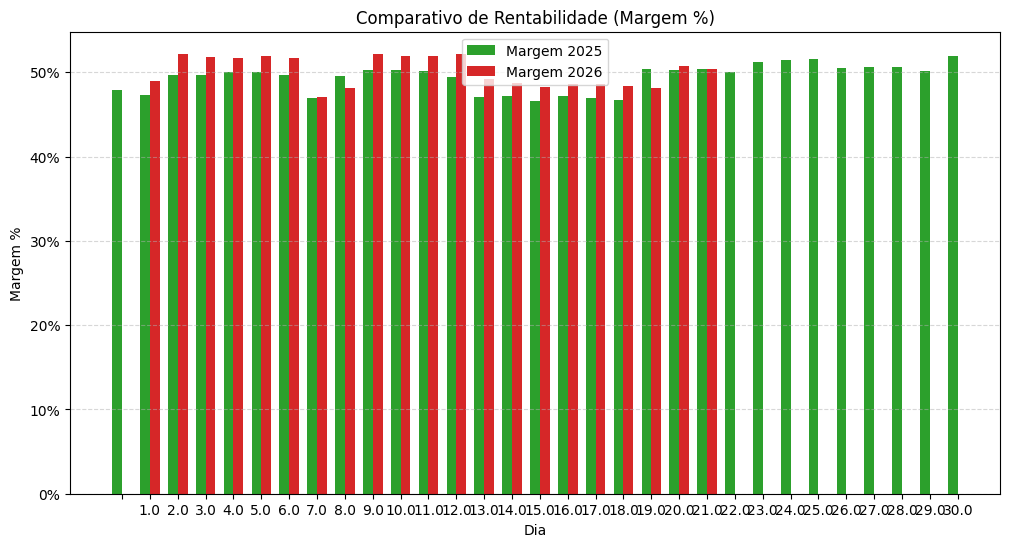

In [14]:
plt.figure(figsize=(12, 6))

width = 0.35
indices = np.arange(len(df))

plt.bar(indices - width/2, df['Marg_2025'], width, label='Margem 2025', color='#2ca02c')
plt.bar(indices + width/2, df['Marg_2026'], width, label='Margem 2026', color='#d62728')

plt.title('Comparativo de Rentabilidade (Margem %)')
plt.xlabel('Dia')
plt.ylabel('Margem %')
plt.xticks(indices, df['Dia'].astype(str).tolist())
plt.legend()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()